In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split,KFold


# Step 1: Import Dataset & Inspect It

In [3]:
housing=fetch_california_housing(as_frame=True)
df=housing.frame

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


# 🔹 STEP 2: Understand the Dataset

In [6]:
df.shape
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.

# 🔹 STEP 3: Basic Statistics (Explicit)

In [7]:
df.describe().loc[['mean','std','min','max']]

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


# 🔹 STEP 4: Data Visualization

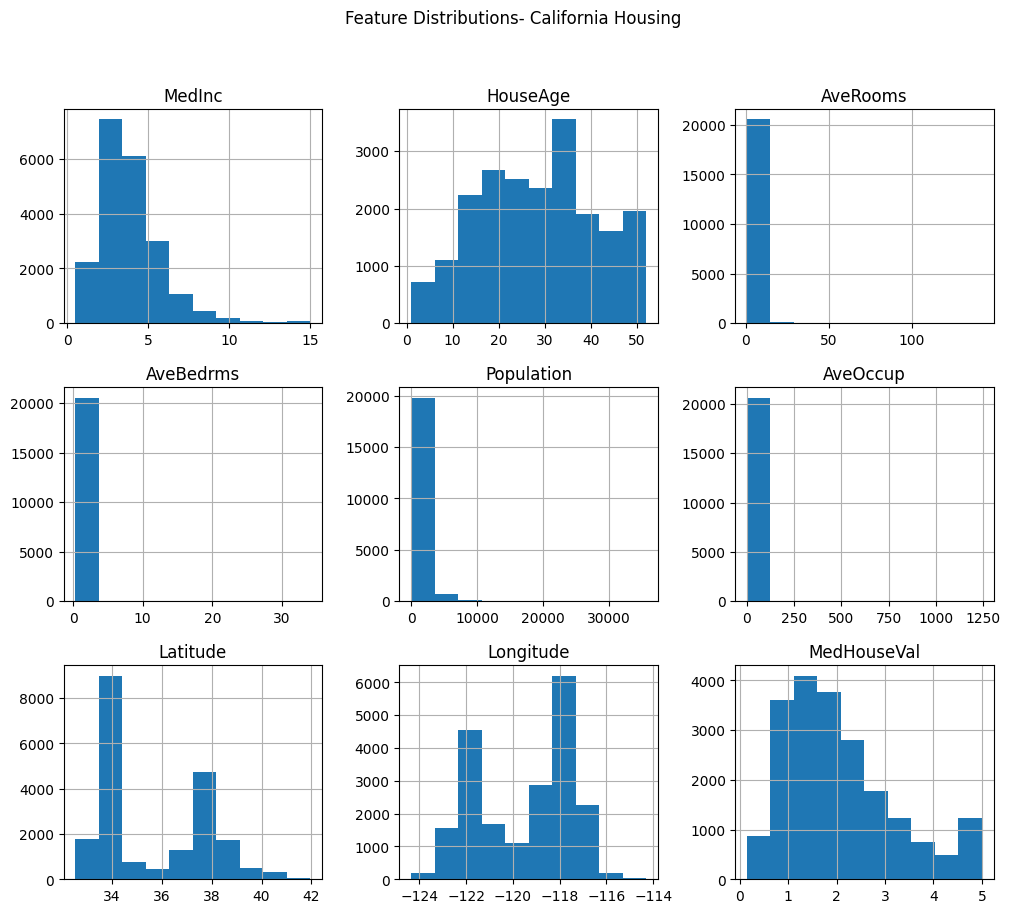

In [8]:
#  Histogram (Feature Distribution)
df.hist(figsize=(12,10))
plt.suptitle("Feature Distributions- California Housing")
plt.show()


### 📦 Boxplot (Outliers Detection)

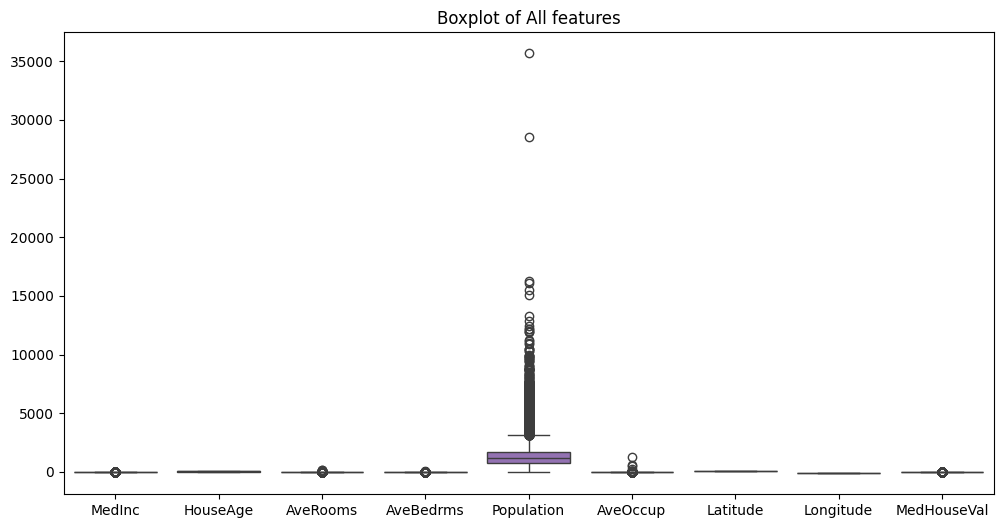

In [12]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.title("Boxplot of All features")
plt.show()

# 🔹 STEP 5: Split Features & Target

In [13]:
X=df.drop('MedHouseVal',axis=1)
y=df['MedHouseVal']

# 🔹 STEP 6: Train–Validation Split (70% / 30%) 

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)
X_train.shape, X_val.shape


((14448, 8), (6192, 8))

# 🔹 STEP 7: Compare Train vs Validation Statistics

In [17]:
train_stats=X_train.describe().loc[['mean','std']]
train_stats

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
mean,3.876892,28.575374,5.438125,1.098033,1427.927326,3.119236,35.650669,-119.584102
std,1.904908,12.613634,2.453569,0.447498,1140.225190,12.373636,2.135742,2.002930


In [18]:
val_stats=X_val.describe().loc[['mean','std']]
val_stats

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
mean,3.856156,28.789083,5.407708,1.093507,1419.758721,2.957299,35.587976,-119.536109
std,1.887973,12.519541,2.521666,0.530476,1114.208253,1.518795,2.135971,2.004694


In [19]:
# Combines both stats for comparison
pd.concat([train_stats,val_stats],keys=['Train','Validation'])

MedInc   HouseAge  AveRooms  AveBedrms   Population  \
Train      mean  3.876892  28.575374  5.438125   1.098033  1427.927326   
           std   1.904908  12.613634  2.453569   0.447498  1140.225190   
Validation mean  3.856156  28.789083  5.407708   1.093507  1419.758721   
           std   1.887973  12.519541  2.521666   0.530476  1114.208253   

                  AveOccup   Latitude   Longitude  
Train      mean   3.119236  35.650669 -119.584102  
           std   12.373636   2.135742    2.002930  
Validation mean   2.957299  35.587976 -119.536109  
           std    1.518795   2.135971    2.004694

# 🔹 STEP 8: Overlapping Distribution Plot

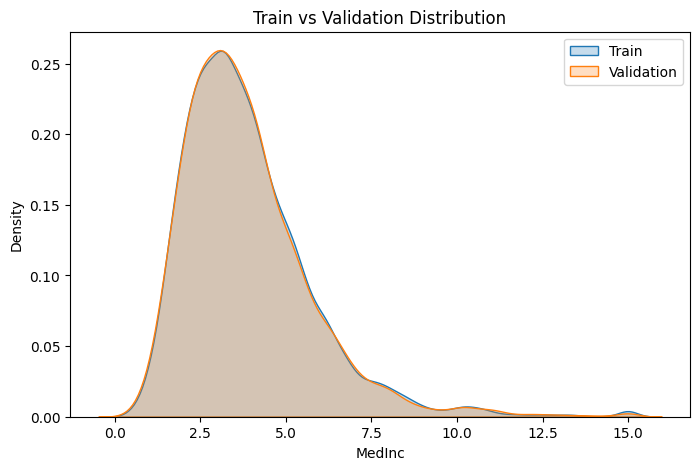

In [21]:
feature = 'MedInc'
plt.figure(figsize=(8, 5))
sns.kdeplot(X_train[feature], label='Train', fill=True)
sns.kdeplot(X_val[feature], label='Validation', fill=True)
plt.legend()
plt.title("Train vs Validation Distribution")
plt.show()


# 🔹 STEP 9: K-Fold Cross-Validation (5 Folds)

In [24]:
from sklearn.model_selection import KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)
for i, (train_idx, val_idx) in enumerate(kf.split(X)):
    print(f"Fold {i+1}: Train = {len(train_idx)}, Validation = {len(val_idx)}")


Fold 1: Train = 16512, Validation = 4128
Fold 2: Train = 16512, Validation = 4128
Fold 3: Train = 16512, Validation = 4128
Fold 4: Train = 16512, Validation = 4128
Fold 5: Train = 16512, Validation = 4128


# 🔹 STEP 10: Feature Mean Variation Across Folds

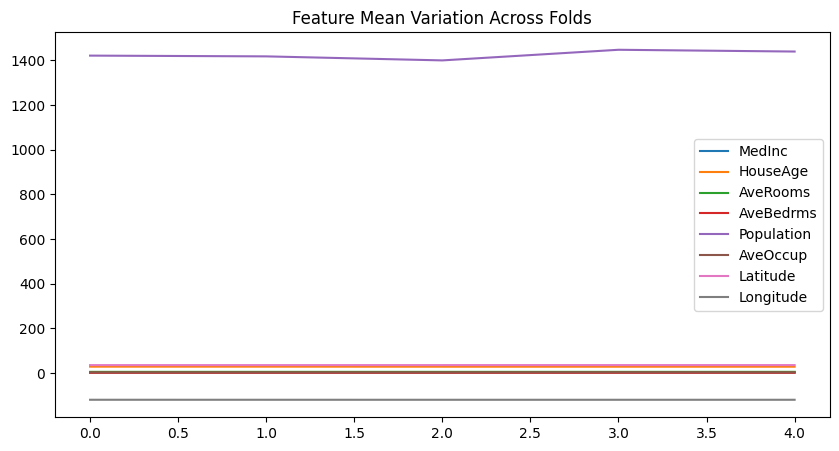

In [ ]:
fold_means = [] # Empty list to store means

# Calculates mean of each fold
for _, val_idx in kf.split(X):
    fold_means.append(X.iloc[val_idx].mean())
    

# Shows stability of data across folds
pd.DataFrame(fold_means).plot(figsize=(10,5))
plt.title("Feature Mean Variation Across Folds")
plt.show()


# 🔹 STEP 11: Hold-Out vs Cross-Validation Comparison

In [28]:
pd.DataFrame({
    "Method": ["Hold-Out", "Cross-Validation"],
    "Splits Used": [1, 5],
    "Reliability": ["Medium", "High"],
    "Time Cost": ["Low", "Higher"]
})


,Method,Splits Used,Reliability,Time Cost
0,Hold-Out,1,Medium,Low
1,Cross-Validation,5,High,Higher
